# Spectral functions in infinite geometries

For an infinite, periodic Hamiltonian, the basic spectral quantities are the total density of
states $A(\omega)=\sum_k\delta(\omega-\epsilon_k)$, `h.get_dos()`, and its momentum-resolved
generalization $A(k,\omega)$, `h.get_kdos_bands()` -- a heatmap of spectral weight vs $(k,\omega)$
that reduces to the ordinary band structure in the clean limit but stays meaningful once a finite
broadening (or interactions/disorder) smear the delta functions into finite-width peaks.

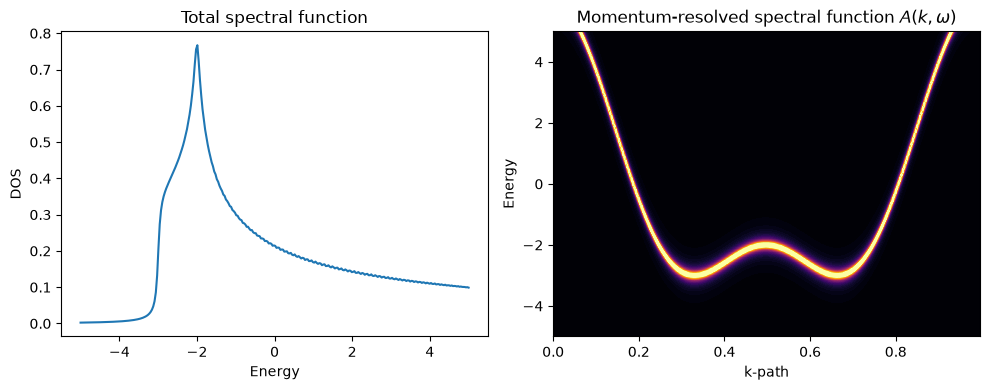

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
g = geometry.triangular_lattice()
h = g.get_hamiltonian()

es,ds = h.get_dos(energies=np.linspace(-5,5,300),delta=0.05,nk=200)

nk = 300
energies = np.linspace(-5,5,120)
kx,ky,d = h.get_kdos_bands(nk=nk,energies=energies,delta=0.1)
dgrid = d.reshape(nk,len(energies)).T

fig,axs = plt.subplots(1,2,figsize=(10,4))
axs[0].plot(es,ds)
axs[0].set_xlabel("Energy") ; axs[0].set_ylabel("DOS")
axs[0].set_title("Total spectral function")
axs[1].contourf(np.unique(kx),energies,dgrid,levels=100,cmap="inferno",vmax=np.percentile(dgrid,99))
axs[1].set_xlabel("k-path") ; axs[1].set_ylabel("Energy")
axs[1].set_title("Momentum-resolved spectral function $A(k,\omega)$")
plt.tight_layout()
plt.show()